<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# some initialization stuff and general imports (see init.py for details)
%run ../init.py
%matplotlib inline

<IPython.core.display.Latex object>

# Representing uncertainty

According to Pearl, uncertainty can arise from many sources:

- *Inherent stochasticity* - dynamics of some systems is random due to natural or predefined reasons
- *Incomplete observability* - many systems appear as stochastic when we cannot understand their behavior due to inability to observe values of all variables
- *Incomplete modeling* - creating models that take all possible observations is quite hard and, therefore, practical models focus only on essential observations
  - Defaults: all birds fly by default, 
  - Incomplete preconditions: there was rain during the night with probability $p$ if grass is wet in the morning  

<div class="cite"> Pearl, J.: Probabilistic reasoning in intelligent systems - networks of plausible inference. Morgan Kaufmann 1989, pp. I-XIX, 1-552</div>

## Representing and reasoning about uncertainty

- Frequentist approach: use historical data to assess frequencies of events and thus determine the probability of this event to occur in repeated experiments (throw dice, measure weight of two year old mice, etc.)
- Bayesian approach: use probability to represent degrees of belief, where 1 means absolute certainty that an event occurs and 0 means the opposite (belief of a doctor that a patient has a decease, consequences of an earthquake, etc.)

In both cases probability can be seen as the extension of logic to deal with uncertainty, see Darwiche (2009)

- Logic allows us to formally determine propositions that hold with respect to given truth assumptions of other variables
- Probability theory - formally determine the likelihood of a proposition to hold given the likelihood of other propositions  
  
<div class="cite">Darwiche, A.: Modeling and Reasoning with Bayesian Networks. Cambridge University Press 2009, pp. I-XII, 1-548</div>

## Random variables

- A *random variable* $\rvar{x}$ 
    - is coupled with a probability distribution that specifies
    - how likely each of its values $x_1,x_2,\dots$ are
- Any random variable can be seen as a representation of possible states
- A *vector-valued random variable* $\vec{\rvar{x}}$ can take a vector of values $\vec{x}$ at random
- Random variables can be 
    - *discrete* - has a finite or countably infinite number of states (named states, integers, etc.), or
    - *continuous* - is associated with an uncountably infinite number of states (real value)

### Discrete variables

- $P(\rvar{x})$ is a *probability mass function* (PMF) that describes a distribution over a discrete variable $\rvar{x}$
  - $P$ must be defined for all possible states of $\rvar{x}$
  - $\forall x \in \rvar{x}, \, 0 \leq P(x) \leq 1$
  - $\sum_{x \in \rvar{x}} P(x) = 1$
  
  
- $P(x)$ - PMF maps from a state $x$ of a random variable $\rvar{x}$ to the probability of $\rvar{x}=x$ 
    - explicitly, $P(\rvar{x}=x)$
    - if the variable was defined first $\rvar{x} \sim P(\rvar{x})$
    
Consider an example of tossing a fair coin - uniform distribution $P(\rvar{x}=x_i) = \frac{1}{k}$, where $k=2$ and $\rvar{x}=\{H,T\}$

- A PMF $\rvar{x,y,}\dots~ \sim P(\rvar{x,y,}\dots)$ defined for multiple variables is called a *joint probability distribution*

Let $\rvar{x}$ denote tossing a fair coin and $\rvar{y}$ throwing a fair dice. How can we define a joint probability distribution $P(\rvar{x,y})$?

$$P(\rvar{x}=x_i,\rvar{y}=y_j) = \frac{1}{k}\cdot\frac{1}{n}$$ 

where $k=2$, since $\rvar{x}=\{H,T\}$, and $n=6$, since $\rvar{x}=\{1,\dots,6\}$

What is the probability of getting a value $3$ as an outcome of throwing a dice?

- *Marginal probability distribution* - a probability distribution over a subset of variables of a joint probability distribution
- *Sum rule*: given $P(\rvar{x},\rvar{y})$ we can find $P(\rvar{x})$ by computing a sum
$$\forall x_i \in \rvar{x} \, P(\rvar{x}=x_i) = \sum_{y_j\in\rvar{y}} P(\rvar{x}=x_i,\mathsf{y}=y_j)$$
    - If a joint probability distribution is written as a table then the sums are usually written on a right *margin* of the table
    

In the example, $P(\rvar{y}=3) = \frac{1}{2}\cdot\frac{1}{6} + \frac{1}{2}\cdot\frac{1}{6} = \frac{1}{6}$

### Continuous variables

- A probability distribution of a continuous random variable is given by a *probability density function* $p$
  - The domain of $p$ must be the set of all possible states of $\rvar{x}$
  - $\forall x \in \rvar{x}, \, p(x) \geq 0$
  - $\int p(x) \, dx = 1$

- Differences to a PMF:
    - $p(x)$ does not give a probability of a specific state $x$ directly
    - $p(x)$ gives a probability $p(x)\delta x$ of getting in a region with a volume $\delta x$
    - Using integration we can find the actual *probability mass* of a set of points, e.g. in an interval $[a,b]$


- Joint probability distributions of continuous variables are defined similarly to the discrete ones
- *Marginal probability distributions* are computed using integration instead of summation 

## Conditional probability

- Probabilistic reasoning (causal modeling) requires to find probabilities of events given that some other events happened
- E.g., what is the probability to observe wet grass in the morning if we know that there was rain in the night?
- Conditional probability
$$P(\rvar{x}=x_i\mid\rvar{y}=y_j) = \frac{P(\rvar{x}=x_i,\rvar{y}=y_j)}{P(\rvar{y}=y_j)}, \quad \text {where } P(\rvar{y}=y_j)>0$$ 
    - This definition is easy to visualize using Venn diagrams
- Bayes rule follows directly from this definition

$$P(\rvar{x}=x_i\mid\rvar{y}=y_j) = \frac{P(\rvar{y}=y_j \mid \rvar{x}=x_i)P(\rvar{x}=x_i)}{P(\rvar{y}=y_j)}$$ 


## Problem: Conditional probability

<div class="mydef">  Assume you roll a fair dice and depending on the outcome select one of the coins to toss. If the dice value is odd you select a fair coin, otherwise you toss a coin with $P(\rvar{c}_u=H)=0.7$. What is the probability to observe tails if you know that the outcome of the dice is an even number?
</div>

- Let $\rvar{d}$, $\rvar{c}_f$, and $\rvar{c}_u$ denote random variables corresponding to the dice, fair, and unfair coins resp.
- Then, $P(\rvar{c}_u=T \lor \rvar{c}_f=T \mid \rvar{d}=\mathit{even}) = P(\rvar{c}_u=T \mid \rvar{d}=\mathit{even}) + P(\rvar{c}_f=T \mid \rvar{d}=\mathit{even})$ since both coins cannot be tossed at the same time (mutually exclusive events)

$$P(\rvar{c}_f=T \mid \rvar{d}=\mathit{even}) = \frac{P(\rvar{c}_f=T, \rvar{d}=\mathit{even})}{P(\rvar{d}=\mathit{even})}=\frac{0 \cdot 0.5}{0.5}=0$$

$$P(\rvar{c}_u=T \mid \rvar{d}=\mathit{even}) = \frac{P(\rvar{c}_u=T, \rvar{d}=\mathit{even})}{P(\rvar{d}=\mathit{even})}=\frac{0.3 \cdot 0.5}{0.5}=0.3$$


## Problem: Bayes rule


<div class="mydef">    
<b> Does a patient have cancer or not?</b>

A patient takes a lab test and the result comes back positive.  The test
returns a correct positive result in only $98\%$ of the cases in which the
disease is actually present, and a correct negative result in only $97\%$ of
the cases in which the disease is not present.  Furthermore, $.008$ of the
entire population have this cancer.
</div>
<p class="fragment step-fade-in-then-out">
\begin{align*}
& P(\rvar{cancer}) =   & & P(\neg \rvar{cancer}) =  \\
& P(\rvar{+} | cancer) =  & &P(\rvar{-} | \rvar{cancer}) =   \\
& P(\rvar{+} | \neg \rvar{cancer}) =   & & P(\rvar{-} | \neg \rvar{cancer}) =  
\end{align*}
</p>
<p class="fragment step-fade-in-then-out">
\begin{align*}
& P(\rvar{cancer}) =  0.008 & & P(\neg \rvar{cancer}) =  0.992\\
& P(\rvar{+} | \rvar{cancer}) =  0.98 & &P(\rvar{-} | \rvar{cancer}) =   0.02\\
& P(\rvar{+} | \neg \rvar{cancer}) =  0.03 & & P(\rvar{-} | \neg \rvar{cancer}) =  0.97
\end{align*}
</p>
<p class="fragment step-fade-in">
    Given a positive test result, can we conclude that a patient has cancer?
</p>
<p class="fragment step-fade-in">
    $cancer$ is our hypothesis $h$ and the test result is our data $D$
</p>
<p class="fragment step-fade-in">
\begin{align*}
& P(\rvar{cancer} | \rvar{+}) \propto P(\rvar{+}|\rvar{cancer})P(\rvar{cancer})= 0.98\cdot 0.008=0.0078  \\
& P(\lnot \rvar{cancer} | \rvar{+}) \propto P(\rvar{+}|\lnot \rvar{cancer})P(\lnot \rvar{cancer})=0.03\cdot 0.992=0.0298
\end{align*}
</p>

### Independence

- Reconsider the experiment with the dice and two coins, but in this case both coins are fair. What is the probability to observe heads if we know that the dice outcome is 3?

- Two random variables $\rvar{x}$ and $\rvar{y}$ are *independent* $\rvar{x} \bot \rvar{y}$ if their joint probability can be expressed as a product

$$P(\rvar{x}=x_i,\rvar{y}=y_j) = P(\rvar{x}=x_i)P(\rvar{y}=y_j)$$ 

- Consequently

$$P(\mathsf{x}=x_i\mid\mathsf{y}=y_j) = P(\mathsf{x}=x_i)$$

### Conditional independence

- Two random variables $\rvar{x}$ and $\rvar{y}$ are *conditionally independent* given variable $\rvar{z}=z$, denoted $\rvar{x} \perp \rvar{y} \mid \rvar{z}$, if

$$P(\rvar{x}=x_i,\rvar{y}=y_j\mid\rvar{z}=z) = P(\rvar{x}=x_i\mid\rvar{z}=z)P(\rvar{y}=y_j\mid\rvar{z}=z)$$ 

- *Independence* is not the same a *mutual exclusiveness*!

- *Problem*: The company employs two security guards A and B and a security system that goes on with a probability of 0.001. 
    - A calls police with the probability of 0.9 and B with 0.5 when alarm is on. 
    - Moreover, when there is no alarm, A might call police with the probability of 0.05 and B with 0.01
    - What is the probability that both A and B call police if the alarm is on?

## Chain rule

- Given the definition of a conditional probability any joint distribution can be decomposed into conditional distributions:

$$P(\rvar{x},\rvar{y},\rvar{z}) = P(\rvar{x} \mid \rvar{y}, \rvar{z}) P(\rvar{y}, \rvar{z}) = P(\rvar{x} \mid \rvar{y}, \rvar{z}) P(\rvar{y} \mid \rvar{z})P(\rvar{z})$$ 

- In a general form:
$$P\left(\rvar{x}^{(1)},\dots,\rvar{x}^{(n)}\right) = P\left(\rvar{x}^{(1)}\right)\prod_{i=2}^n P\left(\rvar{x}^{(i)} \mid \rvar{x}^{(1)},\dots,\rvar{x}^{(i-1)}\right)$$

## Expectation, variance, and bias

- For discrete variables, the expected value of a function $f(x)$ wrt. a probability distribution $P(\rvar{x})$ is defined as
$$\mathbb{E}_{\rvar{x}\sim P}[f(x)] = \sum_x P(x)f(x) $$

- Similarly for continuous variables
$$\mathbb{E}_{\rvar{x}\sim p}[f(x)] = \int p(x)f(x)\, dx $$

- In both cases, can be approximated by a mean of $f$ values computed for $x_n$ sampled from $P$ (third requirement) $\mathbb{E}_{\rvar{x}\sim P}[f(x)] \simeq \frac{1}{N} \sum_{n=1}^N f(x_n)$, which becomes exact when $N \to \infty$

- *Variance* measures how much values of a function $f(x)$ of a random variable $\rvar{x}\sim P$ differ from the expected value $\mathbb{E}[f(x)]$ when $x$ is sampled from $P$

$$\mathrm{Var}(f(x)) = \mathbb{E}\left[(f(x) - \mathbb{E}[f(x)])^2 \right] = \mathbb{E}[(f(x)^2] - \mathbb{E}[f(x)]^2$$

- *Standard deviation* is defined as a square root of the variance
  - Depending on the distribution $P$, the variance of a variable $\rvar{x}$ is often denoted as $\sigma_{\rvar{x}}^2$ and the standard deviation - $\sigma_{\rvar{x}}$  


## Bias vs. variance

- Consider a simple supervised learning problem in which we observe $p$ different values $x_1,\dots,x_p$ of a feature variable $\rvar{x}$ together with $p$ values of a response variable $\rvar{y}$
- Learning always assumes that there is some relationship between the input and response, which can be expressed as some unknown function $f$, namely: $$y = f(x) + \epsilon$$ where $\epsilon$ is a random *error term*, which is independent of the input and has a zero mean, i.e. $\mathbb{E}[\epsilon] = 0$, and, often, unit variance $\mathrm{Var}[\epsilon] = \sigma_\epsilon^2 = 1$
- The essence of learning is to estimate $f$ given $x$ and $y$
- Since the error term averages to zero we can predict $y$ using $$\hat{y} = \hat{f}(x)$$ where $\hat{f}$ is our estimate for $f$ and $\hat{y}$ are the predictions for $y$
- *Bias* of an estimator is defined as a difference of expected value of prediction to the true value $$\mathrm{Bias}[\hat{f}(x)]=\mathbb{E}[\hat{f}(x)]−f(x)$$

<div class="myalert">Finding a <b>balance</b> between bias and variance of an estimator is essential for ML</div>

### Example - Using regression to predict the revenue

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/model_example.csv', sep=';')
df.head()

,Budget,Generator,Revenue
0,1,0.000000,0.430000
1,2,0.693147,1.483147
2,3,1.098612,0.838612
3,4,1.386294,2.026294
4,5,1.609438,0.839438


In [4]:
@interact(show_generator=False)
def plot(show_generator):
    plt.figure(figsize=(10,10))
    sns.scatterplot(x=df.Budget, y=df.Revenue, data=df)
    if show_generator: sns.lineplot(x=df.Budget, y=df.Generator, data=df, color='r')
    plt.show()

interactive(children=(Checkbox(value=False, description='show_generator'), Output()), _dom_classes=('widget-in…

In [5]:
# convert into a column vector
budgetT = df.Budget.values.reshape(-1,1)
# train a linear model
lin_model = LinearRegression().fit(budgetT, df.Revenue)

def regression(df, poly_degree=2, value=10):
    # generate polynomial model of a given degree
    budgetT_deg = PolynomialFeatures(degree=poly_degree, 
                                 include_bias=False).fit_transform(budgetT)
    poly_model = LinearRegression().fit(budgetT_deg, df.Revenue)
    
    # compute a prediction for a value
    b = [[value]]
    b_lin = lin_model.predict(b)[0]
    b_poly = poly_model.predict(PolynomialFeatures(degree=poly_degree, 
                                     include_bias=False).fit_transform(b))[0]
    print('Given the budget of {} (real revenue: {:.2f})'.format(b[0][0], math.log(b[0][0])))
    print('-- Linear model predicts the revenue of {:.2f}'.format(b_lin, 2))
    print('-- Poly model (deg={}) predicts the revenue of {:.2f}'.
          format(poly_degree, b_poly))
    
    # plot the results
    plt.figure(figsize=(10,10))
    l = np.linspace(budgetT.min()-1, budgetT.max()+3, num=100).reshape(-1,1)
    lpoly = PolynomialFeatures(degree=poly_degree, 
                                     include_bias=False).fit_transform(l)
    sns.scatterplot(x=df.Budget, y=df.Revenue, data=df)
    plt.plot(l, lin_model.predict(l), 'r')
    plt.plot(l, poly_model.predict(lpoly), 'g')
    plt.plot([value,value], [b_lin,b_poly], 'o', color='orange')
    plt.show()

In [6]:
interact(regression, df=widgets.fixed(df), poly_degree=(1,9,1), 
         value=(1,budgetT.max()+3,3));

interactive(children=(IntSlider(value=2, description='poly_degree', max=9, min=1), IntSlider(value=10, descrip…



- Consider how well polynomial and linear models fit the training set 
  - The linear model has relatively large *bias*, i.e. it is unable to capture the true relationship because it is biased to "linear" dependencies
  - The polynomial of a high degree fits the training points better and therefore has relatively small bias
- However, predictions of the models for the test point are dramatically different
  - The polynomial has a high *variability* because it results in significantly larger errors for previously unseen data, i.e., this model is *overfit*
  - The linear model makes errors of the same order of magnitude for both training and test data points, i.e., its variability is rather low 
- Ideal model should have low both bias and variability
- Finding the right model is very important!

- The accuracy of $\hat{y}$ depends on *reducible* and *irreducible* errors
  - The error is reducible if it can potentially be improved using a better learning algorithm
  - The irreducible error is due to $\epsilon$, which cannot be improved by any estimation of $f$
    - Unmeasured variables that influence $y$ but we ignore them
    - Unmeasurable variation, e.g., a database can store only values of a given precision, time of events logged on a remote server is imprecise doe to a network latency, etc.
    

$$\mathit{Var}[y] = \mathbb{E}[(y-\mathbb{E}[y])^2]=\mathbb{E}[(f(x)+\epsilon-f(x))^2]=\mathbb{E}[\epsilon^2]=\mathit{Var}[\epsilon]+(\mathbb{E}[\epsilon])^2=\mathit{Var}[\epsilon]$$

- If we consider an *expected squared difference* between the actual $y$ and predicted value $\hat{y}$, then for fixed $\hat{f}$ and $x$, i.e., $\mathbb{E}[\hat{f}(x)]=\hat{f}(x)$, it holds that  

$$
\mathbb{E}[(y-\hat{y})^2] = \mathbb{E}[(f(x)+\epsilon-\hat{f}(x))^2]=(\mathbb{E}[\hat{f}(x)]-f(x))^2 + \mathbb{E}[(f(x)-\mathbb{E}[\hat{f}(x)])^2] + \mathbb{E}[\epsilon^2]=\\\mathit{Bias}[\hat{f}(x)]^2 + \mathit{Var}[\hat{f}(x)] + \mathit{Var}[\epsilon]
$$


- If we have a number of points in the data set then this formula becomes


$$
\mathbb{E}[\mathbb{E}[(y-\hat{y})^2]] = \mathbb{E}[\mathit{Bias}[\hat{f}(x)]^2] + \mathbb{E}[\mathit{Var}[\hat{f}(x)]] + \mathit{Var}[\epsilon]
$$

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/01_Introduction/images/bias-variance.png" width="50%"/>
</center>

<div class="myalert">
    Select a learning method that has both low bias and low variance
</div>

## Example (continued)

Let's illustrate the bias-variance trade-off on a regression problem similar to the one discussed above

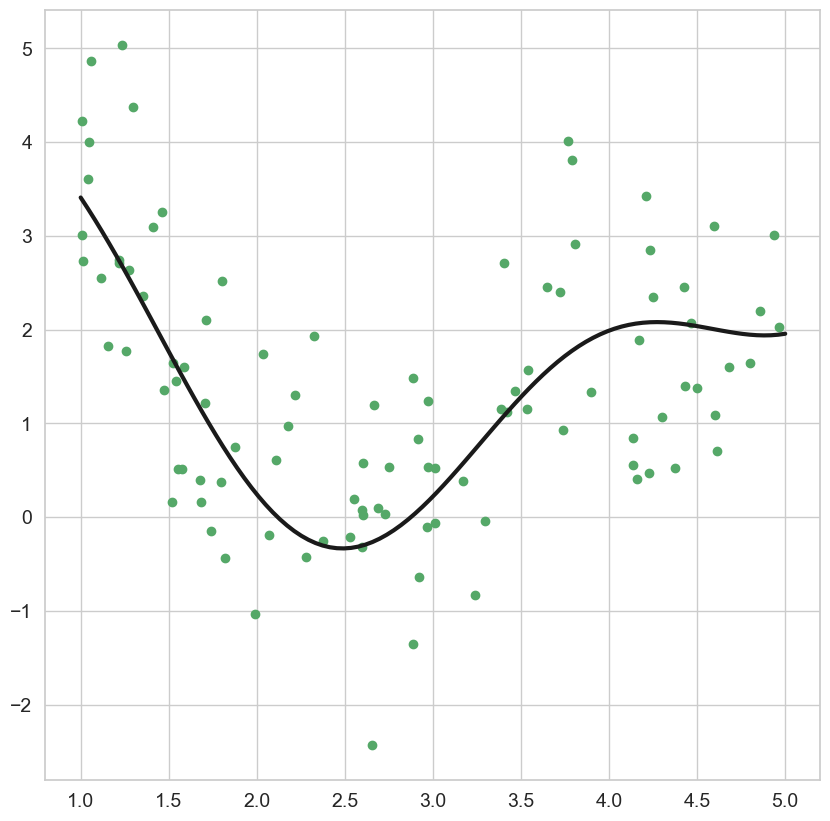

In [7]:
N = 100
sigma_epsilon = 1
x_max=5

epsilon = np.random.normal(0, sigma_epsilon, N)

def f(x):
    return (x**2)/2 - 3*x + 5 +  np.sin(2*x)

X = np.random.uniform(1,x_max, N)
y = f(X) + epsilon

plt.figure(figsize=(10,10))
# plot observations
plt.scatter(X,y,c='g')
# plot real function
x_r = np.linspace(1,x_max,N)
plt.plot(x_r, f(x_r), 'k', linewidth=3);

In [8]:
def plot_bias_variance(X, y, degrees = 5, repeats = 10000):
    train_squared_error = np.zeros((degrees,repeats))
    test_squared_error = np.zeros((degrees,repeats))
    y_hat_store = np.zeros((degrees,repeats,N))
    X_T = X.reshape(-1,1)

    for d in range(degrees):
        for r in range(repeats):
            X_deg = PolynomialFeatures(degree=d+1, 
                                         include_bias=False).fit_transform(X_T)
            # split the data - 20% for training and 80% for testing (simulate sampling from a population)
            X_train, X_test, y_train, y_test = train_test_split(X_deg, y, test_size=round(0.8*N))
            # generate polynomial model of a given degree
            f_hat = LinearRegression().fit(X_train, y_train)
            y_hat = f_hat.predict(X_test)
            # record the results
            train_squared_error[d,r] = np.mean((y_train - f_hat.predict(X_train))**2)
            test_squared_error[d,r] = np.mean((y_hat - y_test)**2)
            y_hat_store[d,r,:] = f_hat.predict(X_deg)

    bias_squared = (np.mean(y_hat_store, 1) - f(X))**2
    var_y_hat = np.var(y_hat_store, 1)

    d_plt = range(1,degrees+1)
    plt.figure(figsize=(10, 10))
    plt.xlim([1,degrees])
    plt.ylim([0,3])
    plt.xticks(d_plt)
    plt.plot(d_plt, np.mean(test_squared_error, 1), 'r', linewidth=3)
    plt.plot(d_plt, np.mean(bias_squared, 1), 'g', linewidth=3)
    plt.plot(d_plt, np.mean(var_y_hat, 1), 'b', linewidth=3)
    plt.plot(d_plt, (sigma_epsilon ** 2) * np.ones_like(d_plt), 'y', linewidth=3)
    plt.plot(d_plt, np.mean(train_squared_error, 1), 'k', linewidth=3)
    plt.legend([r'test squared error - expected $E[(y-\hat{y})^2]$', 
                r'expected $(\mathit{Bias}[\hat{f}(x)])^2$', r'expected $Var[\hat{f}(x)]$', 
                r'$\mathit{Var}[\epsilon]$', 'training squared error'], loc='upper center', fontsize=12)
    ax = plt.gca()
    ax.axvspan(1, 2, alpha=0.3, color='gray')
    ax.axvspan(4, 5, alpha=0.3, color='gray')
    plt.text(1.2,2.8, 'underfitting')
    plt.text(4.2,2.8, 'overfitting')

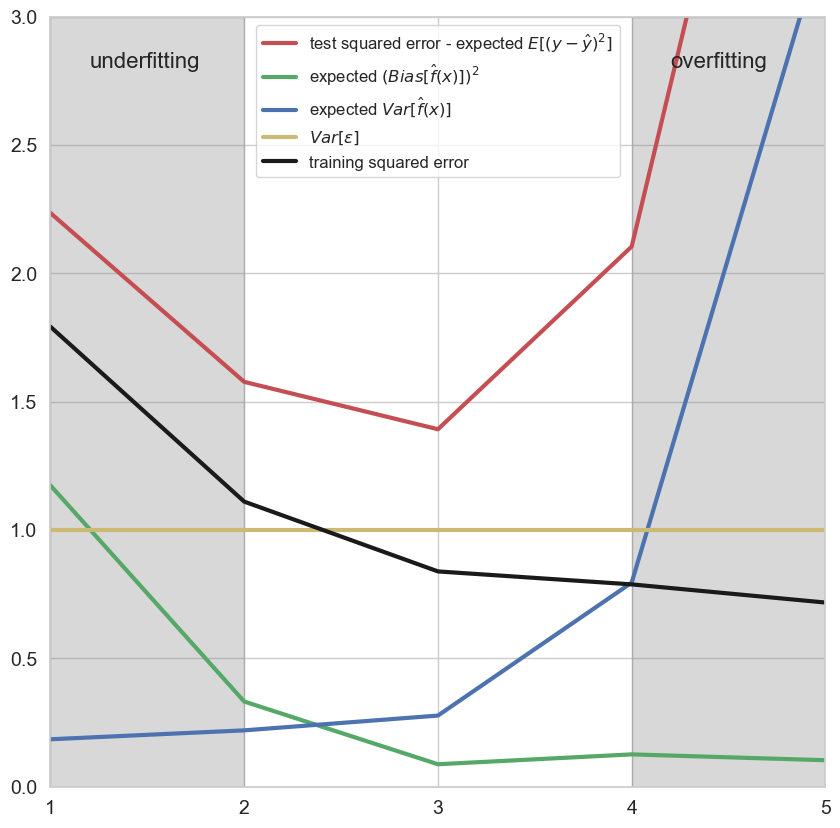

In [9]:
plot_bias_variance(X, y)

## Covariance

- Often we would like to study how much observations of two variables $\rvar{x}$ and $\rvar{y}$ are linearly related to each other and at which scale
- *Covariance* is a common measure of joint variability of two variables $\rvar{x}$ and $\rvar{y}$

$$\mathrm{Cov}(f(x),g(y)) = \mathbb{E}\left[(f(x)-\mathbb{E}[f(x)])\cdot(g(y)-\mathbb{E}[g(y)]) \right]$$
   
- Consequences of the definition:
   - high absolute covariance values means that both values of $\rvar{x}$ and $\rvar{y}$ might simultaneously lie far from their means
   - if $\mathrm{Cov}(f(x),g(y))$ > 0, then both values have a tendency to take values greater or less than mean at the same time
   - otherwise, the values of one variable is higher than the mean and of the other is smaller
   - variance is the covariance of a variable with itself
   - *independent* variables have 0 covariance, but not vice verse, e.g. if the dependence is not linear
   

## Correlation

- Interpretation of covariance might be problematic if two variables have different scales
  - E.g. size of a dog in $mm$ and its body temperature in $^\circ C$ 
- *Correlation* is a normalized version of the covariance, which values can be used to assess the strength of the relation
- *Pearson correlation* is defined as 

$$\rho(f(x),g(y)) = \frac{\mathrm{Cov}(f(x),g(y))}{\mathrm{Cov}(f(x),f(x))\mathrm{Cov}(g(y),g(y))}=\frac{\mathrm{Cov}(f(x),g(y))}{\mathrm{Var}(f(x))\mathrm{Var}(g(y))}$$

- Another possibility is to *rescale* the observations
    - *Standard score* rescales observations to 0 mean (centering) and unit standard deviation - makes the data to take the form of a normal distribution
    $$z_i = \frac{x_i-\mu_\rvar{x}}{\sigma_\rvar{x}}$$
    - *Normal score* - rescaling of observations to the interval $[0,1]$ - special case of min-max scaler
    $$z_i = \frac{x_i-x_\min}{x_\max-x_\min}$$
    where $x_\max$ and $x_\min$ are the maximum and minimum observed values of $\rvar{x}$ resp.

In [10]:
from scipy import stats
import sklearn.datasets as ds

def corr(x, y, **kwargs):
    ax = plt.gca()
    r, p = stats.pearsonr(x, y)    
    ax.annotate('r = {:.2f}\np-value = {:.2f}'.format(r,p), xy = (0.1, 0.3), size = 14, xycoords = ax.transAxes) 
    n_samples = 100

n_samples=100
X,y = ds.make_circles(n_samples, random_state=0)
nr = np.random.normal(0, 1, size=n_samples)
lin = np.linspace(0, 1, num=n_samples)

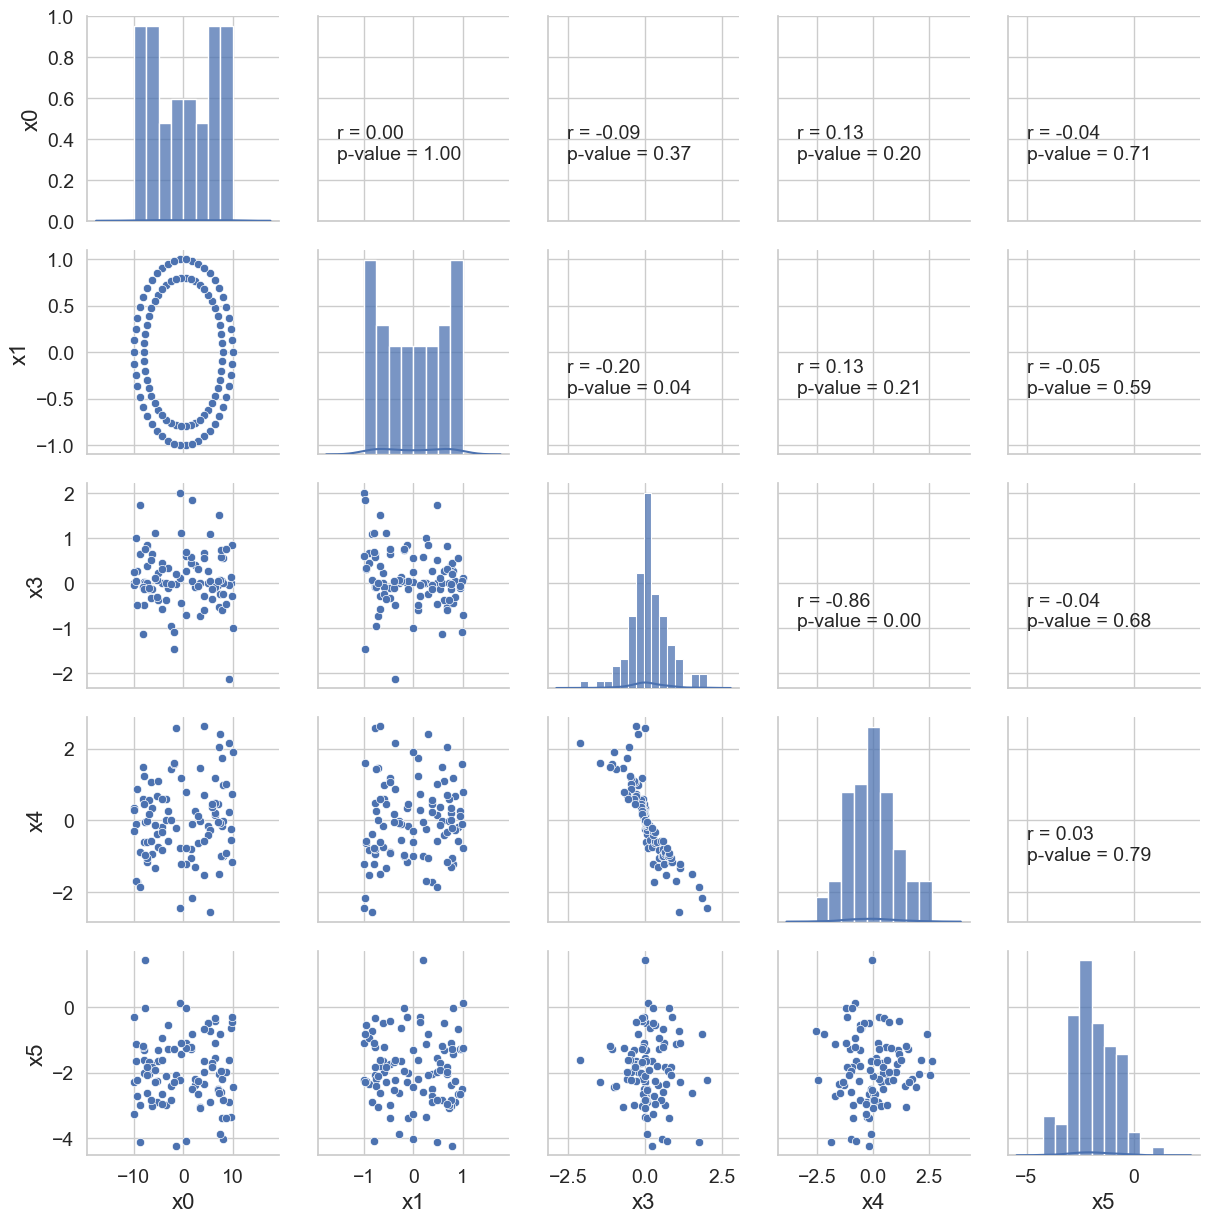

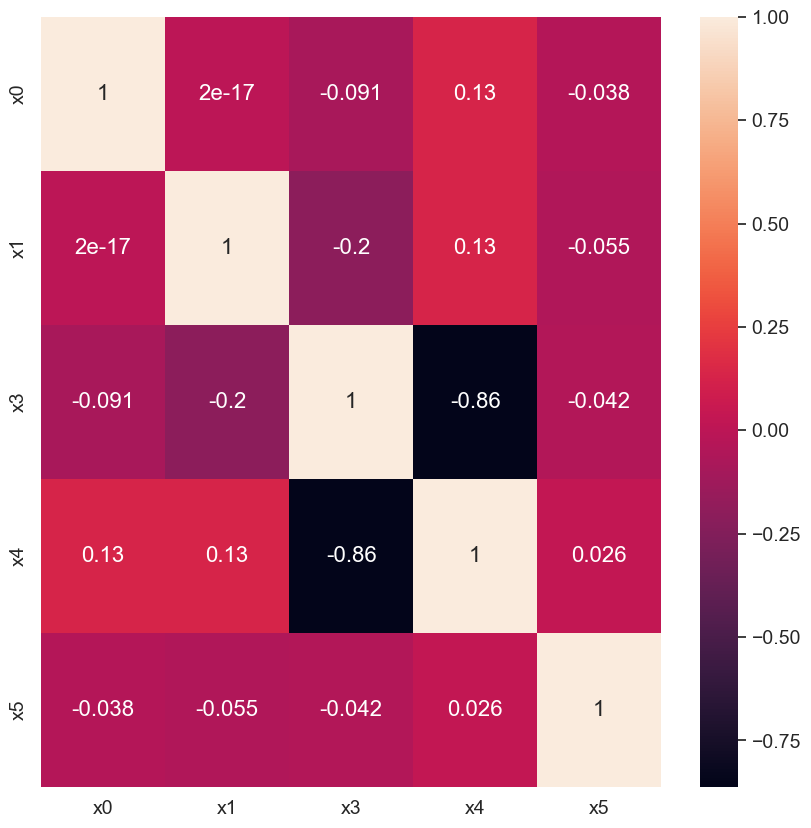

In [11]:
data = pd.DataFrame({'x0':X[:,0]*10, 'x1':X[:,1], 'x3':-lin*nr, 'x4':nr, 'x5':np.random.normal(-2, 1, size=n_samples)})

p = sns.PairGrid(data, diag_sharey=False)
p.map_upper(corr)
p.map_diag(sns.histplot)
p.map_diag(sns.kdeplot)
p.map_lower(sns.scatterplot)
plt.show()

sns.heatmap(data.corr(), annot=True)
plt.show()

In [12]:
# Covariance matrix

data.cov()

,x0,x1,x3,x4,x5
x0,4.141414e+01,-1.052775e-17,-0.374765,0.900640,-0.253806
x1,-1.052775e-17,4.141414e-01,-0.083131,0.089444,-0.036172
x3,-3.747648e-01,-8.313055e-02,0.410826,-0.602750,-0.027713
x4,9.006402e-01,8.944377e-02,-0.602750,1.189648,0.029771
x5,-2.538062e-01,-3.617176e-02,-0.027713,0.029771,1.063101


# Probability distributions

- *Bernoulli distribution* is a distribution over a single *binary* variable $\mathsf{x} \in \{0,1\}$, which is controlled by a parameter $\phi \in [0,1]$

$$P(\rvar{x}=x)=\phi^x(1-\phi)^{1-x}$$

- Therefore, $P(\rvar{x}=1)=\phi$, $P(\rvar{x}=0)=1 - \phi$, $\mathbb{E}_\rvar{x}[\rvar{x}] = \phi$, and $\mathrm{Var}_\rvar{x}(\rvar{x}) = \phi(1-\phi)$
- For example, tossing a fair coin can be modeled with $\phi=0.5$, and an unfair coin $\phi=0.75$


- *Multinoulli distribution* (categorical) is a distribution over a random variable with a finite number of $k$ different states
- This distribution is parametrized by a vector $\vec{p}\in[0,1]^{k-1}$, where each $p_i \in \vec{p}$ gives the probability of the $i$-th state, such that $\sum p_i = n \leq 1$ and $p_k=1-n$
- Example, rolling an unfair dice biased to 6 can be defined by $\vec{p} = \{0.1,\dots,0.1\}$ with $p_6=0.5$

## Normal distribution

- Most common distribution over real numbers is the Gaussian (normal) distribution
$$\mathcal{N}(x; \mu,\sigma^2)=\sqrt{\frac{1}{2\pi\sigma^2}}\exp{\left(-\frac{1}{2\sigma^2}(x-\mu)^2\right)}$$
where parameters $\mu \in \mathbb{R}$ and $\sigma \in \mathbb{R}^+$ control the distribution
- $\mathbb{E}_\rvar{x}[\rvar{x}]=\mu$ and $\mathrm{Var}_\rvar{x}(\rvar{x})=\sigma^2$

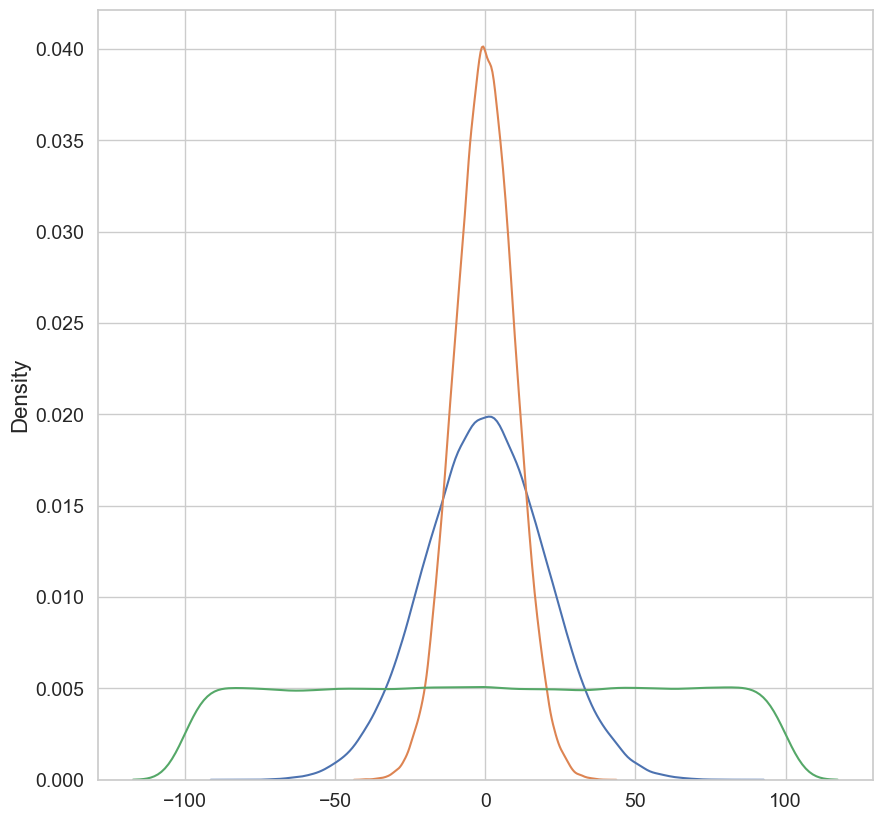

In [13]:
sns.kdeplot(np.random.normal(0,20,100000))
sns.kdeplot(np.random.normal(0,10,100000))
sns.kdeplot(np.random.uniform(-100,100,100000));

- Normal distribution is a common choice in the absence of prior knowledge about the real  distribution over the real numbers
  - Many distributions observed in practice are quite close to the normal one - the *central limit theorem* shows that the sum of many independent random variables is approx. normally distributed
  - It can be shown that out of many possible distributions over the real numbers with the same variance, the normal distribution encodes the maximum amount of uncertainty (i.e., something that we would like to explain)

## Mixtures of distributions

- A *mixture distribution* is composed from a number of *component distributions*
- Given a distribution with $n$ components, the choice of a component which should generate a sample is determined by sampling from a Multinoulli distribution $P(\rvar{c})$ over $n$ states

$$P(\mathsf{x}) = \sum_i P(\rvar{x} \mid \rvar{c}=i)P(\rvar{c}=i)$$ 

- Mixture models are a nice example of a *latent (hidden) variable*, which cannot be observed directly
  - The component $\rvar{c}$ is not observable, but greatly influences the outcomes of $\rvar{x}$
  - $\rvar{x}$ is called a visible variable
- One of the most common mixture models is the Gaussian one, where each $P(\rvar{x} \mid \rvar{c}=i)$ is a Gaussian with a different $\mu$ and $\sigma$
  - Gaussian mixture model with enough components can be used to approximate any smooth density up to some given non-zero error

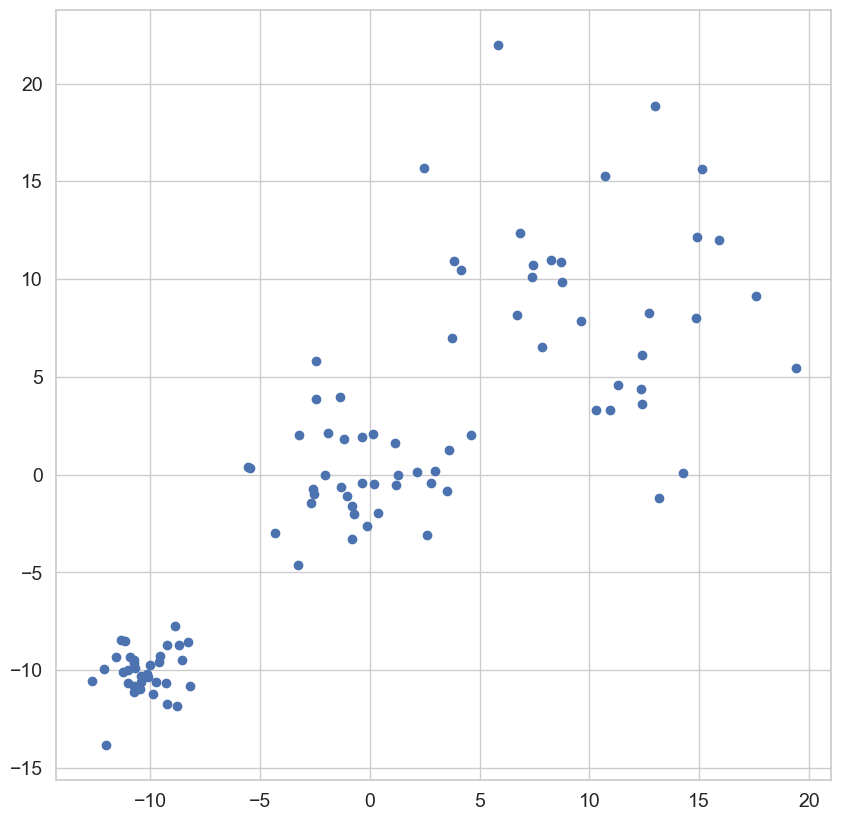

In [14]:
X, _ = ds.make_blobs(n_features=2, centers=[(-10, -10), (0, 0), (10, 10)], cluster_std=(1,2,5))
plt.scatter(X[:,0],X[:,1]);